In [8]:
import tensorflow as tf 
from tensorflow import keras 
from tensorflow.keras import layers 

def create_custom_cnn(input_shape, num_classes): 
    """ 
    Создает кастомную CNN архитектуру - требует строго один размер картинки (к примеру, квадрат)
    """ 
    model = keras.Sequential([ 
        # Входной слой 
        layers.Input(shape=input_shape), 
         
        # Блок 1: Conv + MaxPool - количество фильтров 32
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'), 
        layers.BatchNormalization(), # Ускоряет обучение и стабилизирует веса
        layers.MaxPooling2D((2, 2)), # Уменьшает размер картинки в 2 раза
         
        # Блок 2: Conv + MaxPool - количество фильтров 64
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'), 
        layers.BatchNormalization(), 
        layers.MaxPooling2D((2, 2)), 
         
        # Блок 3: Conv + MaxPool - количество фильтров 128
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
         
        # Полносвязные слои 
        layers.Flatten(), 
        layers.Dense(128, activation='relu'), 
        layers.Dropout(0.5), 
        layers.Dense(num_classes, activation='softmax') 
    ]) 
     
    return model 

In [9]:
# Параметры под твою задачу
IMG_HEIGHT = 128
IMG_WIDTH = 128
CHANNELS = 3      # RGB цвета
NUM_CLASSES = 5   # Bike, Car, FighterJet, Helicopter, Tank

# Создаем модель
input_shape = (IMG_HEIGHT, IMG_WIDTH, CHANNELS)
model = create_custom_cnn(input_shape, NUM_CLASSES)

# Вывод информации о модели (это нужно для отчета!) [cite: 156]
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289,221 (16.36 MB)

 Trainable params: 4,288,773 (16.36 MB)

 Non-trainable params: 448 (1.75 KB)

Часть 3. Обоснование выбора гиперпараметров (2-3 балла)

In [10]:
optimizer = keras.optimizers.Adam(learning_rate=0.001)
loss = 'categorical_crossentropy'
metrics = [
    'accuracy',
    keras.metrics.Precision(name='precision'),
    keras.metrics.Recall(name='recall'),
    keras.metrics.AUC(name='auc')
]

model.compile(optimizer=optimizer, 
             loss=loss, 
             metrics=metrics) 

In [11]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5
    ),
    keras.callbacks.ModelCheckpoint(
        'best_model.h5',
        save_best_only=True,
        monitor='val_accuracy'
    )
]


Сначала загрузим работы, которые получились из main.ipynb

In [12]:
import tensorflow as tf
from tensorflow import keras

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_dataset = keras.preprocessing.image_dataset_from_directory(
    "dataset/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_dataset = keras.preprocessing.image_dataset_from_directory(
    "dataset/validation",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

test_dataset = keras.preprocessing.image_dataset_from_directory(
    "dataset/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_dataset.class_names
print("Классы:", class_names)


Found 3000 files belonging to 5 classes.
Found 505 files belonging to 5 classes.
Found 505 files belonging to 5 classes.
Классы: ['Bike', 'Car', 'FighterJet', 'Helicopter', 'Tank']


In [13]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    batch_size=32,
    callbacks=callbacks
)


Epoch 1/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 551ms/step - accuracy: 0.2226 - auc: 0.5226 - loss: 6.5968 - precision: 0.2449 - recall: 0.1418

94/94 ━━━━━━━━━━━━━━━━━━━━ 64s 624ms/step - accuracy: 0.2087 - auc: 0.5144 - loss: 3.5201 - precision: 0.2454 - recall: 0.0663 - val_accuracy: 0.1881 - val_auc: 0.4962 - val_loss: 1.6141 - val_precision: 0.7500 - val_recall: 0.0059 - learning_rate: 0.0010
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 725ms/step - accuracy: 0.1751 - auc: 0.4870 - loss: 1.6166 - precision: 0.1322 - recall: 8.8410e-04

94/94 ━━━━━━━━━━━━━━━━━━━━ 72s 762ms/step - accuracy: 0.1887 - auc: 0.4939 - loss: 1.6149 - precision: 0.2000 - recall: 0.0010 - val_accuracy: 0.1960 - val_auc: 0.5026 - val_loss: 1.6040 - val_precision: 1.0000 - val_recall: 0.0020 - learning_rate: 0.0010
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 687ms/step - accuracy: 0.1776 - auc: 0.4888 - loss: 1.6125 - precision: 0.0000e+00 - recall: 0.0000e+00

94/94 ━━━━━━━━━━━━━━━━━━━━ 69s 729ms/step - accuracy: 0.1867 - auc: 0.4964 - loss: 1.6127 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.2020 - val_auc: 0.5015 - val_loss: 1.6080 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 89s 939ms/step - accuracy: 0.1923 - auc: 0.5036 - loss: 1.6147 - precision: 0.3750 - recall: 0.0020 - val_accuracy: 0.1782 - val_auc: 0.5120 - val_loss: 1.6194 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 87s 923ms/step - accuracy: 0.1767 - auc: 0.5000 - loss: 1.6091 - precision: 0.5000 - recall: 6.6667e-04 - val_accuracy: 0.1960 - val_auc: 0.4980 - val_loss: 1.6101 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 71s 750ms/step - accuracy: 0.1803 - auc: 0.5004 - loss: 1.6093 - precision: 0.6667 - recall: 6.6667e-04 - val_accuracy: 0.2000 - val_auc

4 Часть 4. Графики обучения и метрики 

Графики обучения 

Проанализируйте графики на предмет переобучения и недообучения:  
• Если обучающий loss снижается, а валидационный растет — переобучение 

• Если оба loss высокие и не улучшаются — недообучение 

• Оптимальная модель: оба loss снижаются, небольшой разрыв между ними 

In [14]:
import matplotlib.pyplot as plt 
 
def plot_training_history(history): 
    """ 
    Строит графики обучения модели 
    """ 
    fig, axes = plt.subplots(2, 2, figsize=(15, 10)) 
     
    # График 1: Loss 
    axes[0, 0].plot(history.history['loss'], label='Train Loss') 
    axes[0, 0].plot(history.history['val_loss'], label='Val Loss') 
    axes[0, 0].set_title('Model Loss') 
    axes[0, 0].set_xlabel('Epoch') 
    axes[0, 0].set_ylabel('Loss') 
    axes[0, 0].legend() 
    axes[0, 0].grid(True) 
     
    # График 2: Accuracy 
    axes[0, 1].plot(history.history['accuracy'], label='Train Accuracy') 
    axes[0, 1].plot(history.history['val_accuracy'], label='Val Accuracy') 
    axes[0, 1].set_title('Model Accuracy') 
    axes[0, 1].set_xlabel('Epoch') 
    axes[0, 1].set_ylabel('Accuracy') 
    axes[0, 1].legend() 
    axes[0, 1].grid(True) 
     
    # График 3: Precision 
    axes[1, 0].plot(history.history['precision'], label='Train Precision') 
    axes[1, 0].plot(history.history['val_precision'], label='Val Precision') 
    axes[1, 0].set_title('Model Precision') 
    axes[1, 0].set_xlabel('Epoch') 
    axes[1, 0].set_ylabel('Precision') 
    axes[1, 0].legend() 
    axes[1, 0].grid(True) 
     
    # График 4: Recall 
    axes[1, 1].plot(history.history['recall'], label='Train Recall') 
    axes[1, 1].plot(history.history['val_recall'], label='Val Recall') 
    axes[1, 1].set_title('Model Recall') 
    axes[1, 1].set_xlabel('Epoch') 
    axes[1, 1].set_ylabel('Recall') 
    axes[1, 1].legend() 
    axes[1, 1].grid(True) 
     
    plt.tight_layout() 
    plt.show()

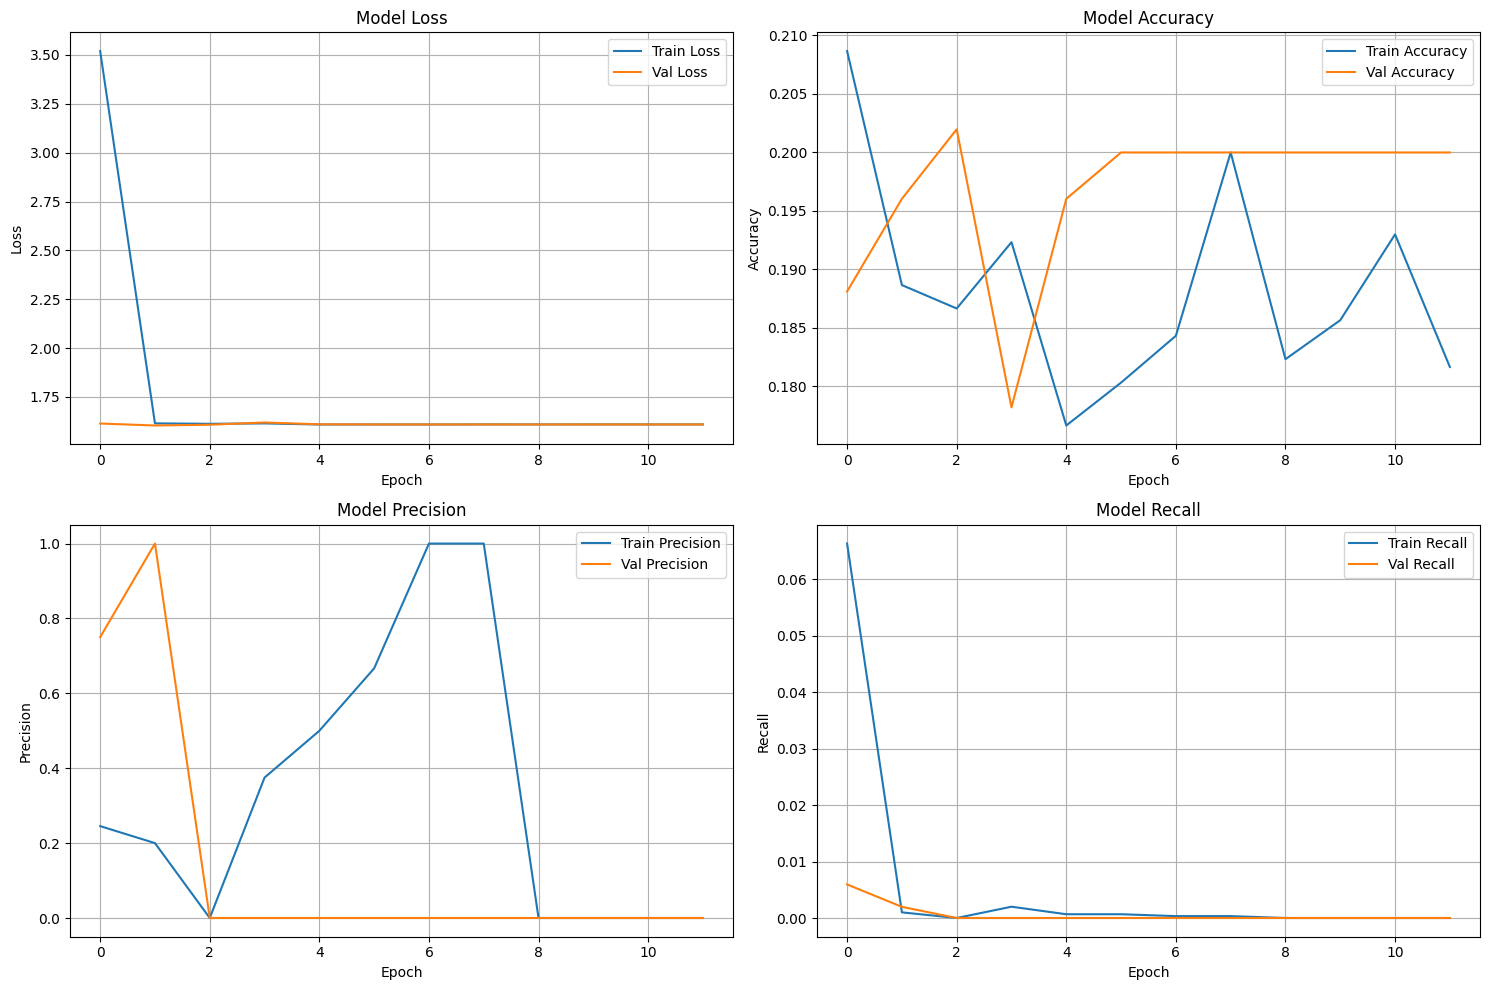

In [15]:
plot_training_history(history)

2. Матрица ошибок (Confusion Matrix)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step


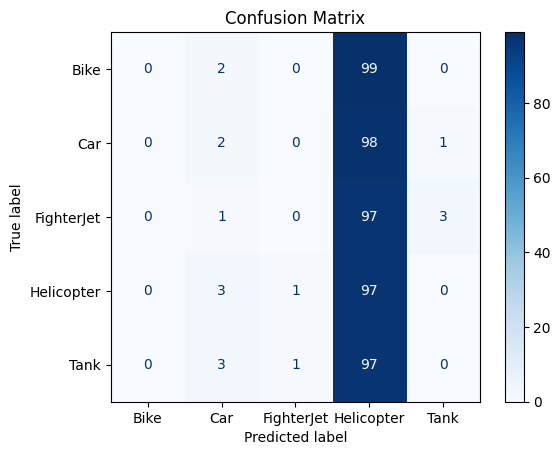

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay 
import numpy as np 
 
# Получение предсказаний на тестовой выборке 
y_pred = model.predict(test_dataset) 
y_pred_classes = np.argmax(y_pred, axis=1) 

# Истинные метки
y_true = np.concatenate([
    np.argmax(labels.numpy(), axis=1)
    for _, labels in test_dataset
])
 
# Построение матрицы ошибок 
cm = confusion_matrix(y_true, y_pred_classes) 
disp = ConfusionMatrixDisplay(confusion_matrix=cm,  
                              display_labels=class_names) 
disp.plot(cmap='Blues', values_format='d') 
plt.title('Confusion Matrix') 
plt.show() 

3. ROC-кривые для каждого класса

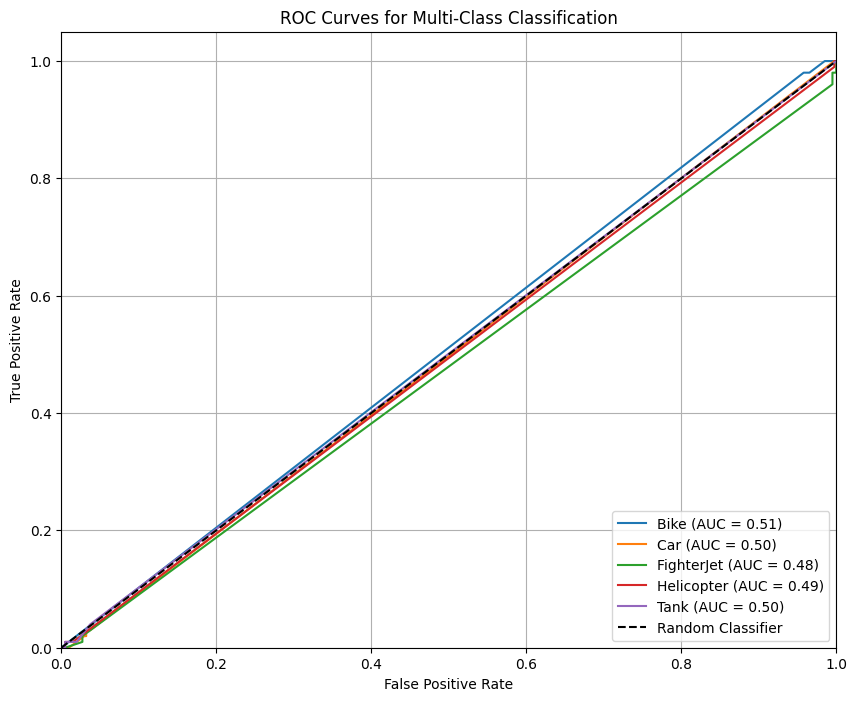

In [19]:
from sklearn.metrics import roc_curve, auc 
from sklearn.preprocessing import label_binarize 
 
# Бинаризация меток для ROC-кривой 
y_test_bin = label_binarize(y_true, classes=range(NUM_CLASSES)) 
 
# Вычисление ROC-кривой для каждого класса 
plt.figure(figsize=(10, 8)) 
for i in range(NUM_CLASSES): 
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred[:, i]) 
    roc_auc = auc(fpr, tpr) 
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})') 
 
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier') 
plt.xlim([0.0, 1.0]) 
plt.ylim([0.0, 1.05]) 
plt.xlabel('False Positive Rate') 
plt.ylabel('True Positive Rate') 
plt.title('ROC Curves for Multi-Class Classification') 
plt.legend(loc="lower right") 
plt.grid(True) 
plt.show() 

4. Таблица метрик по классам

In [20]:
from sklearn.metrics import classification_report 
 
# Вычисление метрик для каждого класса 
report = classification_report(y_true, y_pred_classes,  
                              target_names=class_names, 
                              output_dict=True) 
 
# Создание таблицы 
import pandas as pd 
df_report = pd.DataFrame(report).transpose() 
print(df_report)

              precision    recall  f1-score    support
Bike           0.000000  0.000000  0.000000  101.00000
Car            0.181818  0.019802  0.035714  101.00000
FighterJet     0.000000  0.000000  0.000000  101.00000
Helicopter     0.198770  0.960396  0.329372  101.00000
Tank           0.000000  0.000000  0.000000  101.00000
accuracy       0.196040  0.196040  0.196040    0.19604
macro avg      0.076118  0.196040  0.073017  505.00000
weighted avg   0.076118  0.196040  0.073017  505.00000


c:\Users\nikit\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nikit\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nikit\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave